# RANSAC ground-curvature pipeline — improved

This notebook is the RANSAC counterpart of the Patchwork++ pipeline (v7), restructured so
the two methods produce **directly comparable** outputs:

1. A **forward 1-D road profile** in the same `(z, slope, kappa)` layout as `plot_road_profile` in v7.
2. A polar slope map and polar curvature map for spatial context.

### What changed vs the original RANSAC code

| Issue in original | Fix here |
|---|---|
| Hardcoded plane `(0, 0, 1, 1.87)` only worked for one sensor mounting | Iterative global RANSAC with a height-prior seed — auto-discovers the ground plane |
| float32 throughout | XYZ is promoted to float64 before any plane fitting (precision matters for small cells) |
| `except: continue` swallowed every error | Catches `RuntimeError`/`ValueError` only, so unrelated bugs surface |
| Curvature in degrees of normal change between rings (no length scale) | Curvature normalised by the radial step → physical units of `[1/m]` |
| Curvature contaminated by sidewalks, parked cars, etc. | Forward 1-D profile crops to a strip `\|y\| ≤ y_half_width` around the centerline |
| Could not run on raw nuScenes bins | Works on **either** raw `.bin` **or** Patchwork++-pre-filtered `.bin` (`ALREADY_FILTERED` flag) |

### The ground-filter analogy

Imagine you walk into a cluttered room and want to find the floor. You can't see the floor directly because of furniture, so:

1. **Height prior** — start by looking at the lowest 30% of stuff in the room. Most of that is probably floor or things sitting on the floor.
2. **First guess** — fit a plane through those low things. Even with a few outliers (a low table), RANSAC's "majority wins" rule gives you a reasonable floor estimate.
3. **Refine** — now that you have a candidate floor, *every* point within 20 cm of it is probably actually floor (including spots the height prior missed). Refit on this larger, cleaner set.
4. **Repeat** — three iterations is enough to converge.

This is essentially what GPF (Ground Plane Fit) does, and it's how Patchwork's *concentric zone model* seeds each zone — except we apply it globally rather than per zone. Less powerful than Patchwork++ on heavily sloped terrain, but **far** more robust than a hardcoded number.


In [ ]:
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
#  Paths
# ============================================================
#FILE_PATH = r"C:\Users\JRepa\OneDrive - Delft University of Technology\Documenten\02. TU Delft\2025-2026\BEP\Data\merged_full_scan.bin"
FILE_PATH = r"C:\Users\JRepa\OneDrive - Delft University of Technology\Documenten\02. TU Delft\2025-2026\BEP\Data\Ground points\ground_points.bin"
# Set True if FILE_PATH is already a ground-only cloud (e.g. Patchwork++ output
# saved by v7 cell 9). When True, the global ground-plane step is skipped.
ALREADY_FILTERED = True

# ============================================================
#  Ground segmentation (only used when ALREADY_FILTERED is False)
# ============================================================
GROUND_LOWEST_PCT     = 0.30   # take the lowest 30 % by Z as initial seed
GROUND_DIST_THRESH    = 0.20   # m  -- inlier band around the candidate plane
GROUND_REFINE_ITERS   = 3      # iterative refinement passes
GROUND_RANSAC_ITERS   = 200    # RANSAC iterations per refinement

# ============================================================
#  Polar slope/curvature map (spatial context)
# ============================================================
R_MAX                 = 20.0   # m  -- ignore returns past this range
R_STEP                = 2.0    # m  -- radial bin width
THETA_STEP_DEG        = 3.0    # deg -- angular bin width
MIN_PTS_PER_CELL      = 30
CELL_RANSAC_DIST_THR  = 0.05   # m
CELL_RANSAC_ITERS     = 200

# ============================================================
#  Forward 1-D profile (the v7-comparable output)
# ============================================================
PROFILE_X_RANGE          = (-5.0, 20.0)   # m  forward range (X is forward)
PROFILE_Y_HALF_WIDTH     = 1            # m  strip half-width around centreline
PROFILE_BIN_SIZE         = 0.5            # m  bin width along X
PROFILE_MIN_PTS_PER_BIN  = 5
PROFILE_SMOOTH_WINDOW    = 3              # bins -- light moving average
PROFILE_USE_RANSAC       =True         # True = RANSAC plane per bin
                                          # False = bin median (matches v7)
PROFILE_RANSAC_DIST_THR  = 0.10           # m


## 1. Load the point cloud

Reads a nuScenes-style `.bin` (`float32` x N x 5) and returns just the XYZ
coordinates, **promoted to float64**. The promotion does not recover lost sensor
precision — the original measurement uncertainty is still there — but it keeps
RANSAC's plane-arithmetic from accumulating round-off error inside small cells.


In [82]:
def load_nuscenes_bin(path):
    """Return (N, 3) float64 XYZ from a nuScenes-format .bin file."""
    raw = np.fromfile(path, dtype=np.float32).reshape(-1, 5)
    # nuScenes layout: x, y, z, intensity, ring_index
    return raw[:, :3].astype(np.float64)


points = load_nuscenes_bin(FILE_PATH)
print(f"Loaded {len(points):,} points  (XYZ promoted to float64)")
print(f"X range: {points[:,0].min():+.2f} .. {points[:,0].max():+.2f}  m")
print(f"Y range: {points[:,1].min():+.2f} .. {points[:,1].max():+.2f}  m")
print(f"Z range: {points[:,2].min():+.2f} .. {points[:,2].max():+.2f}  m")


Loaded 32,030 points  (XYZ promoted to float64)
X range: -41.53 .. +47.17  m
Y range: -40.48 .. +47.62  m
Z range: -4.44 .. +6.35  m


## 2. Robust global ground segmentation

This replaces the original `(0, 0, 1, 1.87)` hardcoded plane with an iterative
height-prior RANSAC fit.

The key insight is that **a single RANSAC run on the full cloud often locks onto
the wrong plane** — a building wall, the roof of a parked truck, anything large
and flat-ish. Starting from the lowest 30 % of points by Z biases the first guess
toward actual ground. Each refinement pass then admits all points close to the
current plane (not just the low ones) so a slope rising in front of the sensor
gets picked up rather than rejected as "too high to be ground."

Doesn't work well, it's better to first filter using a different method


In [83]:
def _ransac_plane_fit(pts, dist_thresh, ransac_iters):
    """Local RANSAC plane fit. Returns unit-norm (n, d) with n pointing up.

    Plane convention: n . p + d = 0, so the signed distance of point p
    to the plane is just (p . n + d).
    """
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(pts)
    plane, _ = pcd.segment_plane(
        distance_threshold=dist_thresh,
        ransac_n=3,
        num_iterations=ransac_iters,
    )
    a, b, c, d = plane
    n = np.array([a, b, c], dtype=np.float64)
    nrm = np.linalg.norm(n)
    if nrm < 1e-12:
        return np.array([0.0, 0.0, 1.0]), 0.0
    n /= nrm
    d /= nrm
    if n[2] < 0:                       # ensure normal points up
        n = -n
        d = -d
    return n, d


def estimate_global_ground_plane(points,
                                 lowest_pct=0.30,
                                 dist_thresh=0.20,
                                 n_refine=3,
                                 ransac_iters=200):
    """Iterative height-prior RANSAC.

    Returns (n, d, ground_mask) for the input `points`.

    Pipeline:
      1. Take the lowest `lowest_pct` of points by Z as the seed set.
      2. Fit a RANSAC plane to that set.
      3. Set the new seed set = all original points within `dist_thresh` of
         the current plane (this lets the plane "grow" up onto a slope).
      4. Repeat `n_refine` times.
      5. Final ground mask = signed distance < dist_thresh.
    """
    if len(points) == 0:
        raise ValueError("No points provided.")

    z_thresh = np.percentile(points[:, 2], lowest_pct * 100.0)
    seeds = points[points[:, 2] < z_thresh]
    if len(seeds) < 100:
        seeds = points

    n, d = None, None
    for it in range(n_refine):
        try:
            n, d = _ransac_plane_fit(seeds, dist_thresh, ransac_iters)
        except (RuntimeError, ValueError) as e:
            print(f"  Refine pass {it}: RANSAC failed ({e}). Stopping.")
            break

        signed = points @ n + d
        seeds = points[np.abs(signed) < dist_thresh]
        if len(seeds) < 100:
            print(f"  Refine pass {it}: too few inliers, stopping.")
            break

    if n is None:                      # defensive fallback
        n = np.array([0.0, 0.0, 1.0])
        d = -float(np.median(points[:, 2]))

    mask = np.abs(points @ n + d) < dist_thresh
    return n, d, mask


def get_ground_points(points, already_filtered=False, **kwargs):
    """Returns (ground_pts, n, d). If already_filtered, the input is passed through."""
    if already_filtered:
        return points.copy(), None, None
    n, d, mask = estimate_global_ground_plane(points, **kwargs)
    return points[mask], n, d


# --- run ---
ground, n_g, d_g = get_ground_points(
    points,
    already_filtered=ALREADY_FILTERED,
    lowest_pct=GROUND_LOWEST_PCT,
    dist_thresh=GROUND_DIST_THRESH,
    n_refine=GROUND_REFINE_ITERS,
    ransac_iters=GROUND_RANSAC_ITERS,
)

frac = 100.0 * len(ground) / max(len(points), 1)
print(f"Ground points: {len(ground):,}  ({frac:.1f}% of input)")
if n_g is not None:
    tilt = np.degrees(np.arccos(np.clip(n_g[2], -1.0, 1.0)))
    print(f"Global plane normal : ({n_g[0]:+.3f}, {n_g[1]:+.3f}, {n_g[2]:+.3f})")
    print(f"Plane offset (d)    : {d_g:+.3f} m")
    print(f"Plane tilt vs vert. : {tilt:.2f} deg  (sanity: should be small for level ground)")


Ground points: 32,030  (100.0% of input)


## 3. Sanity check — bird's-eye view

Quick visual confirmation that the ground filter kept the road and rejected
walls/vehicles. Coloured by height — if the colour gradient looks smooth and
ground-like, the segmentation worked.


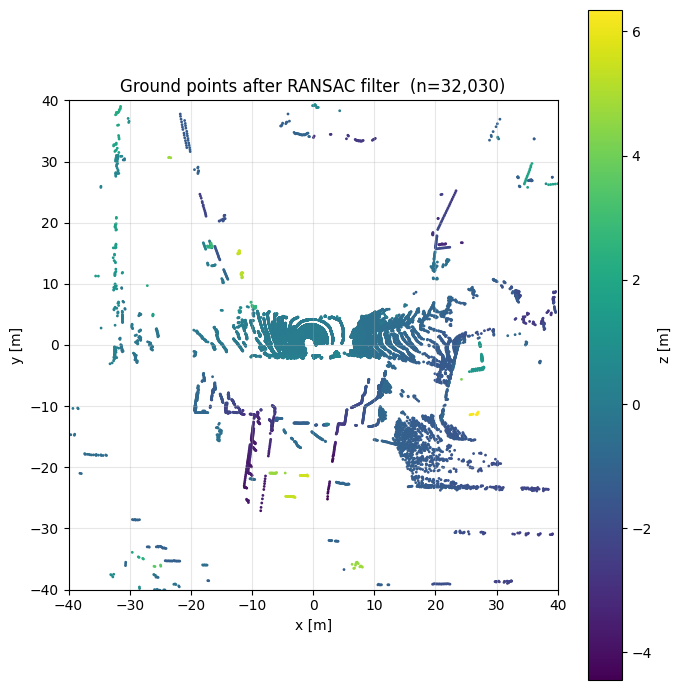

In [84]:
def bev_plot(pts, title="BEV", lim=40, s=1):
    fig, ax = plt.subplots(figsize=(7, 7))
    sc = ax.scatter(pts[:, 0], pts[:, 1], c=pts[:, 2],
                    s=s, cmap="viridis")
    plt.colorbar(sc, ax=ax, label="z [m]")
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")
    ax.set_title(title); ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
    ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()


bev_plot(ground, title=f"Ground points after RANSAC filter  (n={len(ground):,})")


## 4. Polar slope map (spatial context)

Same idea as the original code: divide the ground points into a polar grid and
fit a RANSAC plane in each cell. The slope of that plane (angle between its
normal and vertical) is the value plotted.

The polar grid has the property that **cells far from the sensor are larger in
arc length but identical in radial width** — this matches the LiDAR's actual
sampling density, which thins out azimuthally with range.


Polar cells fit: 297


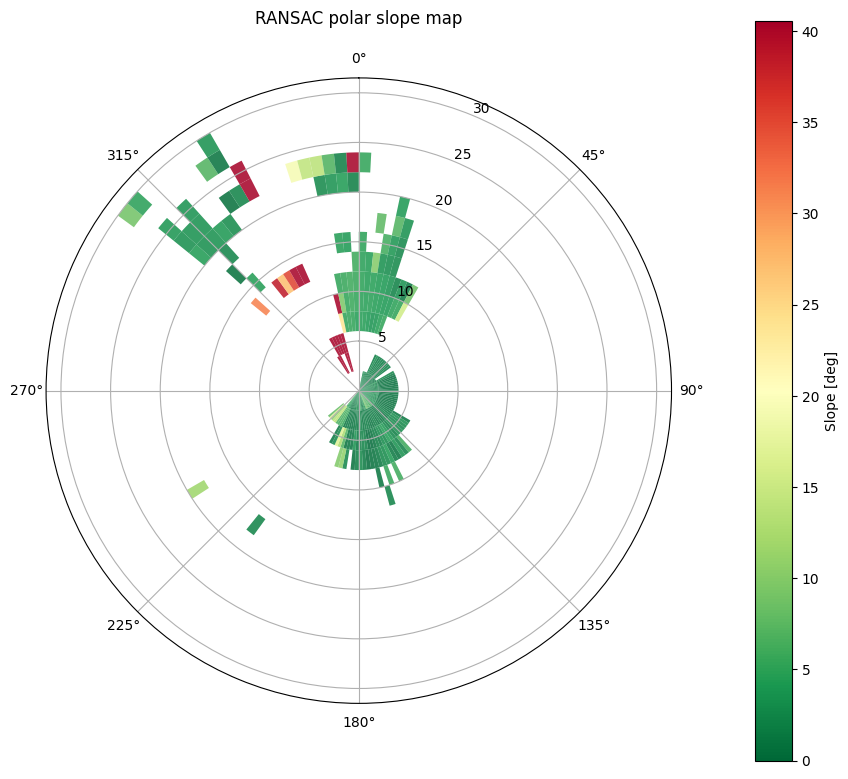

In [85]:
def compute_polar_slopes_ransac(ground_points,
                                r_max=30.0, r_step=2.0,
                                theta_step_deg=5.0,
                                min_pts=12,
                                dist_thresh=0.05,
                                ransac_iters=200):
    """RANSAC plane fit per polar cell.

    Returns a list of dicts with cell bounds, slope (deg), and unit normal.
    """
    if len(ground_points) == 0:
        return []

    x = ground_points[:, 0]
    y = ground_points[:, 1]
    r     = np.sqrt(x * x + y * y)
    theta = np.arctan2(y, x)              # in [-pi, pi]

    keep = r <= r_max
    pts_in = ground_points[keep]
    r_in   = r[keep]
    th_in  = theta[keep]

    r_edges     = np.arange(0.0, r_max + r_step, r_step)
    theta_edges = np.deg2rad(np.arange(-180.0, 180.0 + theta_step_deg, theta_step_deg))

    ir = np.digitize(r_in, r_edges) - 1
    it = np.digitize(th_in, theta_edges) - 1
    ok = (ir >= 0) & (ir < len(r_edges) - 1) & (it >= 0) & (it < len(theta_edges) - 1)
    ir, it, pts_v = ir[ok], it[ok], pts_in[ok]

    z_axis = np.array([0.0, 0.0, 1.0])
    out = []

    # group cells via a single linear key (avoids a double for-loop)
    lin = ir * len(theta_edges) + it
    for key in np.unique(lin):
        cell = pts_v[lin == key]
        if len(cell) < min_pts:
            continue
        try:
            n, _ = _ransac_plane_fit(cell, dist_thresh, ransac_iters)
        except (RuntimeError, ValueError):
            continue
        slope_deg = float(np.degrees(np.arccos(np.clip(n @ z_axis, -1.0, 1.0))))

        i_cell = key // len(theta_edges)
        j_cell = key %  len(theta_edges)
        out.append({
            "r_bounds":     (float(r_edges[i_cell]),     float(r_edges[i_cell + 1])),
            "theta_bounds": (float(theta_edges[j_cell]), float(theta_edges[j_cell + 1])),
            "slope":        slope_deg,
            "normal":       n,
        })
    return out


def plot_polar_slopes(results, title="RANSAC polar slope map"):
    if not results:
        print("No populated cells."); return
    fig = plt.figure(figsize=(9, 8))
    ax = fig.add_subplot(111, projection="polar")
    ax.set_theta_zero_location("N")          # 0 deg = forward (x+)
    ax.set_theta_direction(-1)               # clockwise

    slopes = np.array([r["slope"] for r in results])
    vmax = max(float(np.percentile(slopes, 95)), 1.0)
    cmap = plt.get_cmap("RdYlGn_r")

    for res in results:
        r0, r1 = res["r_bounds"]
        t0, t1 = res["theta_bounds"]
        ax.bar(t0, r1 - r0, width=t1 - t0, bottom=r0,
               color=cmap(min(res["slope"] / vmax, 1.0)),
               align="edge", alpha=0.85, edgecolor="none")

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, vmax))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label="Slope [deg]", pad=0.1)
    plt.title(title, pad=20)
    plt.tight_layout(); plt.show()


polar_results = compute_polar_slopes_ransac(
    ground,
    r_max=R_MAX, r_step=R_STEP, theta_step_deg=THETA_STEP_DEG,
    min_pts=MIN_PTS_PER_CELL,
    dist_thresh=CELL_RANSAC_DIST_THR,
    ransac_iters=CELL_RANSAC_ITERS,
)
print(f"Polar cells fit: {len(polar_results)}")
plot_polar_slopes(polar_results)


## 5. Polar curvature map (rate of normal change)

For each pair of radially adjacent cells in the same angular sector, compute
the angle between their plane normals and divide by the radial step.

$$\kappa_{\text{cell-to-cell}} \;=\; \frac{\arccos(\hat{n}_i \cdot \hat{n}_{i+1})}{\Delta r}\quad [\text{rad/m}] = [1/m]$$

This is a discrete approximation to the derivative of the normal direction along
the radial axis. Unlike the eigenvalue-ratio curvature in v7 (which captures
"how wrinkled is one patch internally"), this one captures **"how fast does
the surface bend as I look outward?"** — a complementary view.

Both are valid but they answer different questions. For comparing against an
IMU's pitch rate while the bike rolls forward, the **forward 1-D profile in the
next section** is the more direct match.


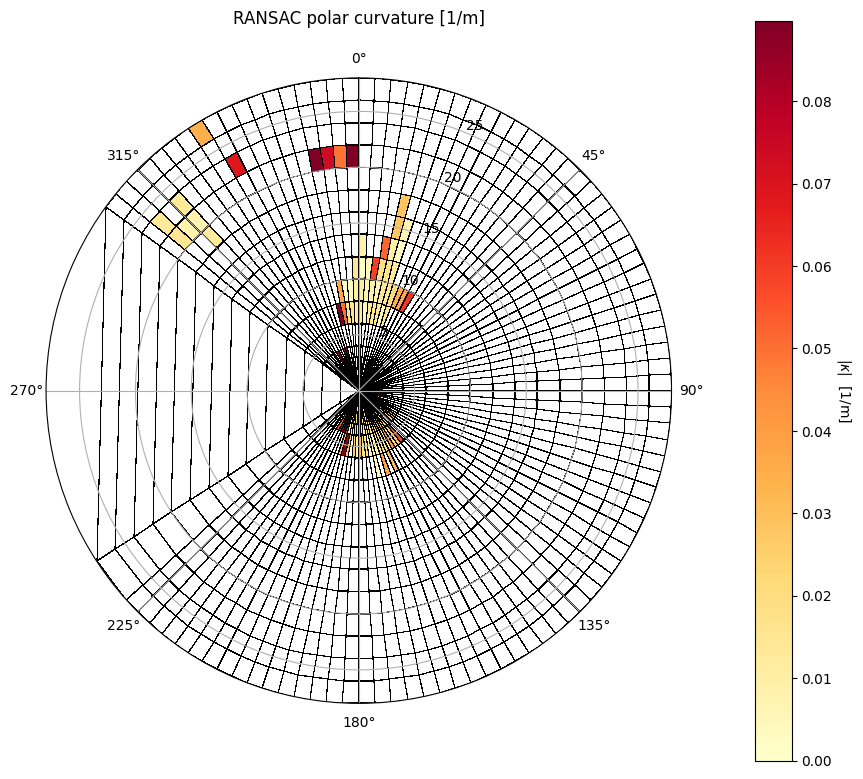

In [86]:
def compute_polar_curvature_radial(results, r_step):
    """Curvature [1/m] as the per-metre angular change of the normal
    between radially adjacent cells in the same angular sector.

    Returns (kappa_matrix, r_boundaries, theta_boundaries) suitable for
    pcolormesh. Kappa is non-negative (we take the magnitude of bending).
    """
    if not results:
        return None, None, None

    r_starts = sorted({res["r_bounds"][0]    for res in results})
    t_starts = sorted({res["theta_bounds"][0] for res in results})
    t_ends   = sorted({res["theta_bounds"][1] for res in results})

    data = {(res["r_bounds"][0], res["theta_bounds"][0]): res["normal"]
            for res in results}

    n_r = len(r_starts) - 1
    n_t = len(t_starts)
    kappa = np.full((n_r, n_t), np.nan)

    for i in range(n_r):
        r_curr, r_next = r_starts[i], r_starts[i + 1]
        for j in range(n_t):
            t = t_starts[j]
            n1 = data.get((r_curr, t))
            n2 = data.get((r_next, t))
            if n1 is None or n2 is None:
                continue
            dot = float(np.clip(np.dot(n1, n2), -1.0, 1.0))
            ang = np.arccos(dot)
            if ang > np.pi / 2:           # handle accidental flips
                ang = np.pi - ang
            kappa[i, j] = ang / r_step    # rad / m == 1/m

    r_b = np.array(r_starts)
    t_b = np.array(t_starts + [t_ends[-1]])
    return kappa, r_b, t_b


def plot_polar_curvature(kappa, r_b, t_b, title="RANSAC polar curvature [1/m]"):
    if kappa is None:
        print("No curvature matrix."); return
    fig = plt.figure(figsize=(9, 8))
    ax = fig.add_subplot(111, projection="polar")
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    mesh = ax.pcolormesh(t_b, r_b, kappa, cmap="YlOrRd",
                         shading="flat", edgecolor="black", linewidth=0.1)
    valid = kappa[~np.isnan(kappa)]
    if len(valid) > 0:
        vmax = max(float(np.percentile(valid, 95)), 1e-3)
        mesh.set_clim(0, vmax)

    cbar = plt.colorbar(mesh, ax=ax, pad=0.1)
    cbar.set_label(r"$|\kappa|$  [1/m]", rotation=270, labelpad=15)
    plt.title(title, pad=20)
    plt.tight_layout(); plt.show()


kappa_polar, r_b, t_b = compute_polar_curvature_radial(polar_results, R_STEP)
plot_polar_curvature(kappa_polar, r_b, t_b)


## 6. Forward 1-D road profile — slope from the RANSAC normal vector

This replaces the previous "median z then differentiate twice" approach.

**Old pipeline:**
$$z_{\text{bin}} = \text{median}(z) \;\to\; \frac{dz}{dx} = \frac{d}{dx} z \;\to\; \frac{d^2z}{dx^2}$$

The trouble: numerical differentiation amplifies noise, and doing it twice amplifies it quadratically. The RANSAC fit had already computed each bin's plane normal — we were just throwing it away.

**New pipeline:**

For each X-bin we fit a plane with RANSAC and read the slope **directly off the plane's normal vector**. The plane equation
$$n_x x + n_y y + n_z z + d = 0$$
solved for $z$ gives $z(x,y) = -(n_x x + n_y y + d)/n_z$, so the forward slope is
$$\frac{dz}{dx} \;=\; -\frac{n_x}{n_z}$$

This is **signed** as long as the normal is forced to point upward ($n_z > 0$):
- $dz/dx > 0$ — riding uphill in $+X$
- $dz/dx < 0$ — riding downhill in $+X$

Curvature is then **one** numerical derivative of the slope (instead of two of $z$):
$$\kappa(x) \;=\; \frac{d^2 z/dx^2}{(1 + (dz/dx)^2)^{3/2}}$$

**Smoothing** is two-stage to handle a few bad bins gracefully:
1. Median filter (kills isolated spikes).
2. Moving average (smooths what remains).

### Why this gives PCA vs RANSAC its fairest comparison

The same function (`compute_road_profile_from_normals`) is used in the v7 notebook with `fit_pca_normal` instead of `fit_ransac_normal`. The output dicts have identical schemas. So when you overlay `profile_v7["slope_deg"]` and `profile_ransac["slope_deg"]` on the same axes, the **only** thing that differs is how each bin's plane normal was estimated:

- **PCA** uses every point, weighted equally → smooth, deterministic, but pulled by outliers.
- **RANSAC** uses only inlier consensus → robust to outliers, but stochastic.

Where they agree: both fits are seeing a clean planar bin and recovering the same normal. Where they disagree: one of them is being pulled by points the other rejected — that's the moment to look at the raw ground points in that bin.


In [87]:
# ============================================================
# Smoothing helpers  --  shared between v7 and RANSAC notebooks
# ============================================================
#
# We use a TWO-STAGE smoothing pipeline:
#   1. Median filter  -- replaces each sample with the median of its
#      neighbours. This kills isolated spikes (one bad bin doesn't move
#      a median, but it does move a mean).
#   2. Moving average -- smooths what survives.
#
# Doing it in this order matters: a moving average alone can't remove a
# single bad sample, it just spreads the badness over its neighbours.
# Median first, mean second.

def _median_filter(y, window):
    """Replace each sample with the median of its `window` neighbours.
    Reflective padding keeps the output the same length as the input."""
    if window <= 1:
        return y.copy()
    pad = window // 2
    y_pad = np.pad(y, pad, mode="reflect")
    out = np.empty_like(y)
    for i in range(len(y)):
        out[i] = np.median(y_pad[i:i + window])
    return out


def _moving_average(y, window):
    """Reflective-padded moving average. Length-preserving."""
    if window <= 1:
        return y.copy()
    pad = window // 2
    y_pad = np.pad(y, pad, mode="reflect")
    kernel = np.ones(window) / window
    return np.convolve(y_pad, kernel, mode="valid")[:len(y)]


In [88]:
# ============================================================
# FORWARD 1-D ROAD PROFILE  --  slope from the plane normal
# ============================================================
#
# Why "from the plane normal"?
#
#   The OLD pipeline took median(z) per bin and then differentiated z
#   numerically twice to get curvature. That throws away everything the
#   plane fit (PCA / RANSAC) actually computed about local orientation,
#   and it amplifies noise quadratically (second derivative).
#
#   The NEW pipeline uses each method's actual output -- the unit normal
#   of the best-fit plane in each bin -- to read the slope DIRECTLY:
#
#       Plane equation:  n_x * x + n_y * y + n_z * z + d = 0
#       Solve for z:     z(x, y) = -(n_x*x + n_y*y + d) / n_z
#       Forward slope:   dz/dx = -n_x / n_z         (signed!)
#
#   Then we differentiate the slope ONCE (instead of z twice) to get
#   d2z/dx2, and apply the full Frenet formula for signed curvature.
#
# Sign convention (with n_z > 0 enforced):
#       dz/dx > 0   ->  going UPHILL in +X  (z increases forward)
#       dz/dx < 0   ->  going DOWNHILL in +X
#       kappa < 0   ->  hill crest (concave down)
#       kappa > 0   ->  valley bottom (concave up)


def compute_road_profile_from_normals(ground_points,
                                      fit_normal,
                                      x_range=(-5.0, 25.0),
                                      y_half_width=1.5,
                                      bin_size=0.5,
                                      min_pts=8,
                                      median_window=5,
                                      smooth_window=7,
                                      method_label="(unspecified)"):
    """Forward 1-D road profile.  Slope comes from each bin's plane normal.

    Parameters
    ----------
    ground_points : (N, 3) array, X forward, Y left, Z up.
    fit_normal    : callable.  fit_normal(bin_pts) -> upward unit normal (3,).
    x_range       : (x_min, x_max) forward extent in metres.
    y_half_width  : strip half-width [m]; only |y| <= this is used.
    bin_size      : X bin width [m].
    min_pts       : minimum points per bin to attempt a plane fit.
    median_window : odd int, median-filter window (outlier rejection).
    smooth_window : odd int, moving-average window after the median filter.
    method_label  : "PCA" or "RANSAC", used in the plot title only.
    """
    # 1. crop a forward strip around the centreline
    m = ((ground_points[:, 0] >= x_range[0]) &
         (ground_points[:, 0] <= x_range[1]) &
         (np.abs(ground_points[:, 1]) <= y_half_width))
    pts = ground_points[m]
    if len(pts) < 10:
        print("Not enough ground points in the forward strip.")
        return None

    # 2. set up X bins
    x_edges   = np.arange(x_range[0], x_range[1] + bin_size, bin_size)
    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
    n_bins = len(x_centers)

    # 3. per-bin: median z (height) + signed slope from plane normal
    z_bin    = np.full(n_bins, np.nan)
    dzdx_bin = np.full(n_bins, np.nan)

    for i in range(n_bins):
        in_bin = (pts[:, 0] >= x_edges[i]) & (pts[:, 0] < x_edges[i + 1])
        bin_pts = pts[in_bin]
        if len(bin_pts) < min_pts:
            continue

        # height: median is robust to a few residual outliers
        z_bin[i] = float(np.median(bin_pts[:, 2]))

        # slope: read directly off the plane fit's normal
        try:
            n = fit_normal(bin_pts)
            if abs(n[2]) > 1e-6:
                dzdx_bin[i] = -n[0] / n[2]      # signed dz/dx
        except Exception:
            pass    # leave NaN, will be interpolated

    valid_z = ~np.isnan(z_bin)
    valid_s = ~np.isnan(dzdx_bin)
    if valid_z.sum() < 5 or valid_s.sum() < 5:
        print("Not enough populated bins for a profile.")
        return None

    # 4. interpolate over NaN gaps so derivatives are defined everywhere
    z_filled    = np.interp(x_centers, x_centers[valid_z], z_bin[valid_z])
    dzdx_filled = np.interp(x_centers, x_centers[valid_s], dzdx_bin[valid_s])

    # 5. robust two-stage smoothing  (median first, mean second)
    z_med    = _median_filter(z_filled,    median_window)
    dzdx_med = _median_filter(dzdx_filled, median_window)
    z_smooth    = _moving_average(z_med,    smooth_window)
    dzdx_smooth = _moving_average(dzdx_med, smooth_window)

    # 6. ONE differentiation of the slope -> second derivative
    d2zdx2 = np.gradient(dzdx_smooth, bin_size)

    # 7. signed curvature with full Frenet formula
    kappa  = d2zdx2 / (1.0 + dzdx_smooth ** 2) ** 1.5
    with np.errstate(divide="ignore"):
        radius = np.where(np.abs(kappa) > 1e-6, 1.0 / np.abs(kappa), np.inf)

    return dict(
        x=x_centers,
        z=z_smooth,
        z_raw=z_bin,
        slope_deg=np.degrees(np.arctan(dzdx_smooth)),
        slope_raw_deg=np.degrees(np.arctan(dzdx_bin)),
        kappa=kappa,
        kappa_abs=np.abs(kappa),
        radius=radius,
        valid_z_mask=valid_z,
        valid_s_mask=valid_s,
        bin_size=bin_size,
        method=method_label,
    )


def plot_road_profile(prof):
    """Three-panel plot: height, slope, signed curvature.
    Same layout in v7 (PCA) and RANSAC notebooks for direct overlay comparison."""
    if prof is None:
        return

    fig, ax = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

    # --- 1. height ---
    ax[0].plot(prof["x"], prof["z"], "-", lw=1.5, color="tab:blue",
               label="z(x) (smoothed)")
    ax[0].plot(prof["x"][prof["valid_z_mask"]],
               prof["z_raw"][prof["valid_z_mask"]],
               "o", ms=4, color="tab:orange", label="bin medians (raw)")
    ax[0].set_ylabel("Ground height z  [m]")
    ax[0].set_title(f"Forward road profile  --  slope from {prof['method']} plane normal")
    ax[0].grid(True); ax[0].legend()

    # --- 2. slope (signed, from plane normal) ---
    ax[1].plot(prof["x"], prof["slope_deg"], "-", color="tab:green",
               lw=1.5, label="slope (smoothed)")
    ax[1].plot(prof["x"][prof["valid_s_mask"]],
               prof["slope_raw_deg"][prof["valid_s_mask"]],
               "o", ms=3, color="tab:olive", alpha=0.5, label="raw (per bin)")
    ax[1].axhline(0, color="k", lw=0.5)
    ax[1].set_ylabel("Slope [deg]  (signed)")
    ax[1].grid(True); ax[1].legend()

    # --- 3. signed curvature ---
    k = prof["kappa"]
    pos = k >= 0
    ax[2].fill_between(prof["x"], k, 0, where=pos, color="tab:blue", alpha=0.35,
                       label=r"$\kappa > 0$  (valley bottom)")
    ax[2].fill_between(prof["x"], k, 0, where=~pos, color="tab:red", alpha=0.35,
                       label=r"$\kappa < 0$  (hill crest)")
    ax[2].plot(prof["x"], k, "-", color="k", lw=1)
    ax[2].axhline(0, color="k", lw=0.5)
    ax[2].set_xlabel("X (forward) [m]")
    ax[2].set_ylabel(r"Curvature $\kappa$ [1/m]  (signed)")
    ax[2].grid(True); ax[2].legend(loc="upper right")

    plt.tight_layout(); plt.show()

    # numerical summary
    print(f"Method        : {prof['method']}")
    print(f"Mean slope    : {prof['slope_deg'].mean():+6.2f}  deg")
    print(f"Mean kappa    : {prof['kappa'].mean():+7.4f}  1/m")
    print(f"Max |kappa|   : {prof['kappa_abs'].max():7.4f}  1/m")
    if prof['kappa_abs'].max() > 1e-6:
        print(f"Min radius    : {1.0 / prof['kappa_abs'].max():7.1f}  m")
    n_pos = int((prof['kappa'] > 0).sum())
    n_neg = int((prof['kappa'] < 0).sum())
    print(f"Concave-up    : {n_pos:3d} bins  (valley-shaped)")
    print(f"Concave-down  : {n_neg:3d} bins  (hill-shaped)")


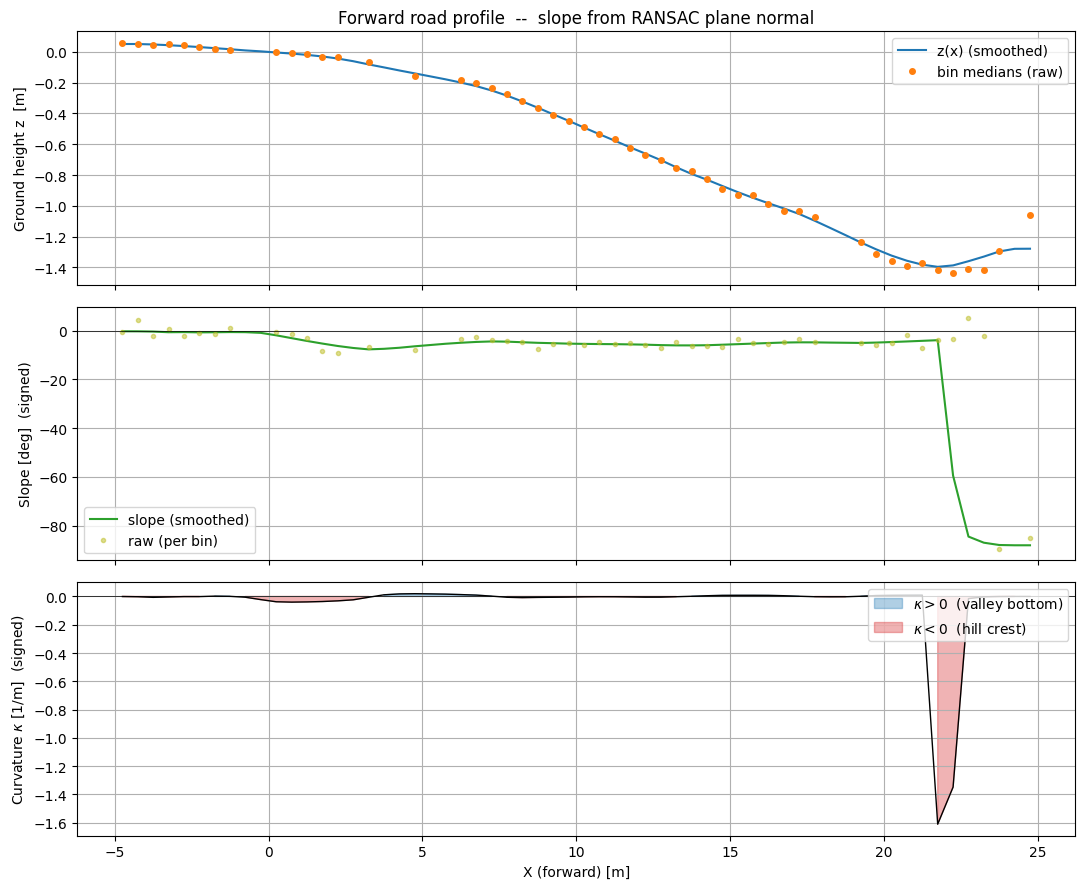

Method        : RANSAC
Mean slope    : -12.17  deg
Mean kappa    : -0.0518  1/m
Max |kappa|   :  1.6106  1/m
Min radius    :     0.6  m
Concave-up    :  23 bins  (valley-shaped)
Concave-down  :  36 bins  (hill-shaped)


In [89]:
# ============================================================
# Per-bin RANSAC plane fit  --  reuses _ransac_plane_fit from earlier
# ============================================================
#
# How RANSAC finds a plane:
#   Try many random triplets of points. For each triplet, fit a plane
#   and count how many of the OTHER points lie within `dist_thresh` of
#   it. Keep the plane with the most "inliers". This rejects outliers
#   that PCA would let pull the eigenvector.
#
#   RANSAC is stochastic -- the same data can give slightly different
#   normals on re-runs -- but more robust to bad points within the bin.

def fit_ransac_normal(bin_pts, dist_thresh=0.05, ransac_iters=100):
    """RANSAC plane fit. Returns upward-pointing unit normal (3,)."""
    n, _d = _ransac_plane_fit(bin_pts, dist_thresh, ransac_iters)
    if n[2] < 0:
        n = -n
    return n


# ============================================================
# Run on the ground points and plot
# ============================================================
profile_ransac = compute_road_profile_from_normals(
    ground,                                       # from the global RANSAC ground filter (cell 5)
    fit_normal=fit_ransac_normal,
    x_range=PROFILE_X_RANGE,
    y_half_width=PROFILE_Y_HALF_WIDTH,
    bin_size=PROFILE_BIN_SIZE,
    min_pts=PROFILE_MIN_PTS_PER_BIN,
    median_window=5,
    smooth_window=7,
    method_label="RANSAC",
)
plot_road_profile(profile_ransac)


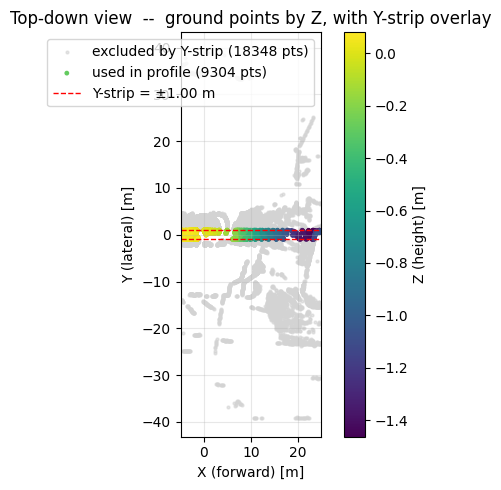

In [90]:
x_min, x_max = PROFILE_X_RANGE
y_strip      = PROFILE_Y_HALF_WIDTH

in_x      = (ground[:, 0] >= x_min) & (ground[:, 0] <= x_max)
in_strip  = in_x & (np.abs(ground[:, 1]) <= y_strip)
in_excl   = in_x & ~in_strip

pts_used     = ground[in_strip]
pts_excluded = ground[in_excl]

fig, ax = plt.subplots(1, 1, figsize=(12, 5))

if len(pts_excluded):
    ax.scatter(pts_excluded[:, 0], pts_excluded[:, 1],
               c="lightgrey", s=4, alpha=0.6,
               label=f"excluded by Y-strip ({len(pts_excluded)} pts)")

if len(pts_used):
    sc = ax.scatter(pts_used[:, 0], pts_used[:, 1],
                    c=pts_used[:, 2], cmap="viridis", s=6,
                    label=f"used in profile ({len(pts_used)} pts)")
    cbar = plt.colorbar(sc, ax=ax, pad=0.02)
    cbar.set_label("Z (height) [m]")

ax.axhline( y_strip, color="red", lw=1.0, ls="--",
            label=f"Y-strip = ±{y_strip:.2f} m")
ax.axhline(-y_strip, color="red", lw=1.0, ls="--")

ax.set_xlim(x_min, x_max)
ax.set_xlabel("X (forward) [m]")
ax.set_ylabel("Y (lateral) [m]")
ax.set_title("Top-down view  --  ground points by Z, with Y-strip overlay")
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 7. Direct comparison with v7

Both notebooks now produce a `profile` dict with the same keys (`x`, `z`,
`slope_deg`, `kappa`, ...). Plot them on the same axes:

```python
fig, ax = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
for prof, label, color in [(profile_v7,     "PCA (v7)",     "tab:blue"),
                           (profile_ransac, "RANSAC",       "tab:orange")]:
    ax[0].plot(prof["x"], prof["z"],         color=color, label=label)
    ax[1].plot(prof["x"], prof["slope_deg"], color=color, label=label)
    ax[2].plot(prof["x"], prof["kappa"],     color=color, label=label)
ax[0].set_ylabel("z [m]")
ax[1].set_ylabel("slope [deg]")
ax[2].set_ylabel(r"$\kappa$ [1/m]"); ax[2].set_xlabel("X (forward) [m]")
for a in ax: a.grid(True); a.legend()
plt.tight_layout(); plt.show()
```

### What you actually compare now

- **Height z(x)**: both use median z per bin -- they should agree to within
  centimetres on flat sections. Disagreements here are pure ground-filter
  artefacts (the input ground point sets differ).
- **Slope**: this is now the genuine head-to-head between PCA and RANSAC.
  Same input points (when the ground filters agree), different plane fitter,
  signed slope from the normal. Disagreements reveal bins where one method
  was pulled by outliers the other rejected.
- **Curvature**: one numerical derivative of slope. Differences amplify
  slope disagreements -- if PCA and RANSAC give the same slope curve, they
  give the same curvature curve.

### For the BEP report

This is the experiment that actually answers the question "is PCA or RANSAC
the better local plane fitter for the SenseBike's ground curvature
estimation":

1. Run both notebooks on the same frame.
2. Overlay slope curves. Note bins with > 1 deg disagreement.
3. Cross-validate against the IMU's pitch rate (next chapter).
4. Whichever method's slope tracks the IMU more closely is the one to
   recommend in the conclusion.
